# Checkpoint Two: Exploratory Data Analysis

Now that your chosen dataset is approved, it is time to start working on your analysis. Use this notebook to perform your EDA and make notes where directed to as you work.

## Getting Started

Since we have not provided your dataset for you, you will need to load the necessary files in this repository. Make sure to include a link back to the original dataset here as well.

My dataset:https://www.kaggle.com/datasets/tonygordonjr/zillow-real-estate-data?utm_source=chatgpt.com
&select=listing_mortgage_info.csv


Your first task in EDA is to import necessary libraries and create a dataframe(s). Make note in the form of code comments of what your thought process is as you work on this setup task.

In [31]:
# Importing pandas for data manipulation and analysis.
import pandas as pd

# Importing numpy for numerical operations.
import numpy as np

# Importing matplotlib for data visualization.

import matplotlib.pyplot as plt



## Get to Know the Numbers

Now that you have everything setup, put any code that you use to get to know the dataframe and its rows and columns better in the cell below. You can use whatever techniques you like, except for visualizations. You will put those in a separate section.

When working on your code, make sure to leave comments so that your mentors can understand your thought process.

In [32]:
property_df = pd.read_csv("../Data/Final Project Datasets/property_listings.csv")
subtype_df  = pd.read_csv("../Data/Final Project Datasets/listing_subtype.csv")
nearby_df   = pd.read_csv("../Data/Final Project Datasets/listing_nearby_homes.csv")





In [33]:
#The next 3 cells is a preview of my datasets. I just want to make
#sure they loaded correctly. 
property_df.head()

,zpid,price,homeStatus,homeType,datePosted,streetAddress,city,state,zipcode,county,...,rentZestimate,bathrooms,bedrooms,pageViewCount,favoriteCount,propertyTaxRate,timeOnZillow,dateSold,url,lastUpdated
0,32107262.0,750000.0,Recently Sold,Multi Family,2024-03-19,7417 87th Rd,Jamaica,NY,11421.0,Queens County,...,2930.0,2.0,NaN,20.0,0.0,0.86,9 hours,2024-11-24,https://www.zillow.com/homedetails/7417-87th-R...,2024-11-25 09:04:11.007468 UTC
1,20503342.0,3995.0,Recently Sold,Apartment,2024-09-24,1300 Midvale Ave APT 510,Los Angeles,CA,90024.0,Los Angeles County,...,3867.0,2.0,2.0,187.0,5.0,1.16,9 hours,2024-11-24,https://www.zillow.com/homedetails/1300-Midval...,2024-11-25 09:04:11.007468 UTC
2,20183958.0,820000.0,Recently Sold,Single Family,2024-10-27,8300 Capps Ave,Northridge,CA,91324.0,Los Angeles County,...,4540.0,2.0,3.0,21.0,0.0,1.16,9 hours,2024-11-24,https://www.zillow.com/homedetails/8300-Capps-...,2024-11-25 09:04:11.007468 UTC
3,32332472.0,550000.0,Recently Sold,Single Family,2024-07-09,433 Hamden Ave,Staten Island,NY,10306.0,Richmond County,...,2668.0,1.0,2.0,96.0,0.0,0.89,9 hours,2024-11-24,https://www.zillow.com/homedetails/433-Hamden-...,2024-11-25 09:04:11.007468 UTC
4,352427429.0,703478.0,Recently Sold,Single Family,2024-06-19,504 Edwin St #8,Nashville,TN,37207.0,Davidson County,...,3599.0,4.0,4.0,7.0,0.0,0.57,9 hours,2024-11-24,https://www.zillow.com/homedetails/504-Edwin-S...,2024-11-25 09:04:11.007468 UTC


In [34]:
subtype_df.head()


,zpid,is_FSBA,is_comingSoon,is_newHome,is_pending,is_forAuction,is_foreclosure,is_bankOwned,is_openHouse,is_FSBO,lastUpdated
0,348939329,False,False,True,False,False,False,False,False,False,2024-11-20 23:54:07.345926 UTC
1,442720817,False,False,True,False,False,False,False,False,False,2024-11-20 23:54:07.345926 UTC
2,442717169,False,False,True,False,False,False,False,True,False,2024-11-20 23:54:07.345926 UTC
3,442707890,False,False,True,False,False,False,False,False,False,2024-11-20 23:54:07.345926 UTC
4,43812298,False,False,True,False,False,False,False,False,False,2024-11-20 23:54:07.345926 UTC


In [35]:
nearby_df.head()


,zpid,zpidComp,addressComp,cityComp,stateComp,zipComp,priceComp,homeTypeComp,homeStatusComp,livingAreaValueComp,livingAreaUnitsComp,lotAreaValueComp,lotAreaUnitsComp,lastUpdated
0,35846147,35846218,217 Whitaker Cir NW,Atlanta,GA,30314.0,148400,Single Family,Other,923.0,Square Feet,10380.0,Square Feet,2024-11-20 23:54:06.908546 UTC
1,35846147,35846218,217 Whitaker Cir NW,Atlanta,GA,30314.0,148400,Single Family,Other,923.0,Square Feet,10380.0,Square Feet,2024-11-20 22:18:43.363748 UTC
2,35846147,35846219,223 Whitaker Cir NW,Atlanta,GA,30314.0,137500,Single Family,Other,936.0,Square Feet,10201.0,Square Feet,2024-11-20 22:18:43.363748 UTC
3,35846147,35846219,223 Whitaker Cir NW,Atlanta,GA,30314.0,137500,Single Family,Other,936.0,Square Feet,10201.0,Square Feet,2024-11-20 23:54:06.908546 UTC
4,35846147,35846220,229 Whitaker Cir NW,Atlanta,GA,30314.0,176800,Condo,Other,1504.0,Square Feet,9962.0,Square Feet,2024-11-20 22:18:43.363748 UTC


In [36]:
# The next 3 cells, checking the shape of the dataframe 
# (rows, columns) to see how many listings are included and
# how many variables are available.
property_df.shape

(18778, 23)

In [37]:
subtype_df.shape


(18415, 11)

In [38]:
nearby_df.shape


(239767, 14)

In [39]:
# The next 3 cells, I want to see what kind of data do I have
# in each dataset. Basicly, are there any data types that are 
# mixed match or throwing an excessive amount of errors. 

property_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18778 entries, 0 to 18777
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   zpid             18777 non-null  float64
 1   price            18777 non-null  float64
 2   homeStatus       18777 non-null  object 
 3   homeType         18777 non-null  object 
 4   datePosted       18750 non-null  object 
 5   streetAddress    18777 non-null  object 
 6   city             18777 non-null  object 
 7   state            18777 non-null  object 
 8   zipcode          18777 non-null  float64
 9   county           18763 non-null  object 
 10  yearBuilt        18025 non-null  float64
 11  livingArea       17669 non-null  float64
 12  livingAreaUnits  17673 non-null  object 
 13  rentZestimate    13691 non-null  float64
 14  bathrooms        18304 non-null  float64
 15  bedrooms         18119 non-null  float64
 16  pageViewCount    18776 non-null  float64
 17  favoriteCoun

In [40]:
subtype_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18415 entries, 0 to 18414
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   zpid            18415 non-null  int64 
 1   is_FSBA         18415 non-null  bool  
 2   is_comingSoon   18415 non-null  bool  
 3   is_newHome      18415 non-null  bool  
 4   is_pending      18415 non-null  bool  
 5   is_forAuction   18415 non-null  bool  
 6   is_foreclosure  18415 non-null  bool  
 7   is_bankOwned    18415 non-null  bool  
 8   is_openHouse    18415 non-null  bool  
 9   is_FSBO         18415 non-null  bool  
 10  lastUpdated     18415 non-null  object
dtypes: bool(9), int64(1), object(1)
memory usage: 449.7+ KB


In [41]:
nearby_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239767 entries, 0 to 239766
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   zpid                 239767 non-null  int64  
 1   zpidComp             239767 non-null  int64  
 2   addressComp          239749 non-null  object 
 3   cityComp             239766 non-null  object 
 4   stateComp            239762 non-null  object 
 5   zipComp              239759 non-null  float64
 6   priceComp            239767 non-null  int64  
 7   homeTypeComp         239767 non-null  object 
 8   homeStatusComp       239767 non-null  object 
 9   livingAreaValueComp  213820 non-null  float64
 10  livingAreaUnitsComp  213820 non-null  object 
 11  lotAreaValueComp     178238 non-null  float64
 12  lotAreaUnitsComp     239767 non-null  object 
 13  lastUpdated          239767 non-null  object 
dtypes: float64(3), int64(3), object(8)
memory usage: 25.6+ MB


In [42]:
# Generating summary statistics for numeric columns
# so I can look into value ranges, averages,
# and potential outliers and should be addressed during 
# data cleaning.
property_df.describe()

,zpid,price,zipcode,yearBuilt,livingArea,rentZestimate,bathrooms,bedrooms,pageViewCount,favoriteCount,propertyTaxRate
count,1.877700e+04,1.877700e+04,18777.000000,18025.000000,17669.000000,13691.000000,18304.000000,18119.000000,18776.000000,18776.000000,18776.000000
mean,2.631983e+08,6.730238e+05,51667.758428,1975.274896,1878.425887,2949.399240,4.736806,6.220211,203.498029,12.473477,1.034852
std,5.277399e+08,3.630882e+06,28080.881461,88.593346,1349.086211,2943.427583,284.604419,381.164350,396.750776,27.479579,0.491043
min,1.069739e+06,0.000000e+00,2108.000000,0.000000,0.000000,673.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.624716e+07,2.525000e+05,30047.000000,1950.000000,1190.000000,1801.000000,2.000000,3.000000,50.000000,2.000000,0.670000
50%,5.296319e+07,3.999990e+05,44135.000000,1980.000000,1633.000000,2338.000000,2.000000,3.000000,120.000000,6.000000,0.860000
75%,3.219012e+08,6.900000e+05,78249.000000,2008.000000,2266.000000,3293.500000,3.000000,4.000000,235.000000,14.000000,1.470000
max,2.146974e+09,4.750000e+08,98199.000000,9999.000000,49087.000000,108970.000000,38451.000000,51268.000000,18880.000000,1518.000000,2.000000


In [43]:
# Looking at the numeric columns to make sure that the 
# identifier fields are reasonable and the booleans are
# correctly represented

subtype_df.describe()


,zpid
count,1.841500e+04
mean,2.642590e+08
std,5.291305e+08
min,1.069739e+06
25%,2.627357e+07
50%,5.338958e+07
75%,3.314841e+08
max,2.146974e+09


In [44]:
# Looking for missing values, value ranges and any outliers
# in comparable property metrics

nearby_df.describe()

,zpid,zpidComp,zipComp,priceComp,livingAreaValueComp,lotAreaValueComp
count,2.397670e+05,2.397670e+05,239759.000000,2.397670e+05,2.138200e+05,178238.000000
mean,2.612188e+08,3.380370e+08,50374.637720,5.869492e+05,2.615020e+03,3655.541031
std,5.254332e+08,6.583392e+08,27661.079937,2.715997e+06,1.308039e+05,3329.056054
min,1.069739e+06,3.251670e+05,2108.000000,0.000000e+00,0.000000e+00,0.000000
25%,2.096809e+07,2.640553e+07,30041.000000,1.850000e+05,1.144000e+03,2.350000
50%,5.336331e+07,5.548190e+07,40228.000000,3.411000e+05,1.561000e+03,3150.000000
75%,3.054332e+08,2.498989e+08,78228.000000,5.902280e+05,2.195000e+03,6385.000000
max,2.146974e+09,2.146998e+09,98199.000000,1.371996e+08,3.963501e+07,99999.000000


In [45]:

# In the next 3 cells, checking for missing values in each column.
property_df.isna().sum()

zpid                   1
price                  1
homeStatus             1
homeType               1
datePosted            28
streetAddress          1
city                   1
state                  1
zipcode                1
county                15
yearBuilt            753
livingArea          1109
livingAreaUnits     1105
rentZestimate       5087
bathrooms            474
bedrooms             659
pageViewCount          2
favoriteCount          2
propertyTaxRate        2
timeOnZillow         319
dateSold           15092
url                    1
lastUpdated            0
dtype: int64

In [46]:
subtype_df.isna().sum()

zpid              0
is_FSBA           0
is_comingSoon     0
is_newHome        0
is_pending        0
is_forAuction     0
is_foreclosure    0
is_bankOwned      0
is_openHouse      0
is_FSBO           0
lastUpdated       0
dtype: int64

In [47]:
nearby_df.isna().sum()

zpid                       0
zpidComp                   0
addressComp               18
cityComp                   1
stateComp                  5
zipComp                    8
priceComp                  0
homeTypeComp               0
homeStatusComp             0
livingAreaValueComp    25947
livingAreaUnitsComp    25947
lotAreaValueComp       61529
lotAreaUnitsComp           0
lastUpdated                0
dtype: int64

In [48]:
# Inspecting unique values for selected categorical columns
# so I can understand the variety of property types
# and listing statuses present in the dataset.
property_df["homeType"].unique()

array(['Multi Family', 'Apartment', 'Single Family', 'Condo', 'Townhouse',
       'Lot', 'Manufactured', nan], dtype=object)

In [49]:
property_df["homeStatus"].unique()


array(['Recently Sold', 'For Sale', 'Pending', 'Foreclosed', 'For Rent',
       'Pre Foreclosure', nan, 'Other'], dtype=object)

In [50]:

# Viewing the distribution of listings by state.
# This helps me identify which geographic areas are
# most represented in the dataset.
property_df["state"].value_counts()

state
TX    3288
FL    1820
GA    1606
NY    1561
CA    1499
NV    1214
PA    1162
IL    1043
OH     802
TN     675
NC     569
AZ     566
IN     523
MD     506
KY     424
CO     371
MI     362
WA     280
VA     192
MA     166
SC     148
Name: count, dtype: int64

## Visualize

Create any visualizations for your EDA here. Make note in the form of code comments of what your thought process is for your visualizations.

In [51]:
# Converting the datePosted column to datetime so it can be used
# for time-based grouping and trend analysis.
property_df["datePosted"] = pd.to_datetime(property_df["datePosted"])

In [52]:
# Filtering the data to focus on listings from 2022 to 2024.
property_2022_2024 = property_df[
    (property_df["datePosted"].dt.year >= 2022) &
    (property_df["datePosted"].dt.year <= 2024)
]

In [53]:
# Grouped by year and calculate the average listing price.
# This helps me answer how property values have changed over time.
avg_price_by_year = (
    property_2022_2024
    .groupby(property_2022_2024["datePosted"].dt.year)["price"]
    .mean()
)

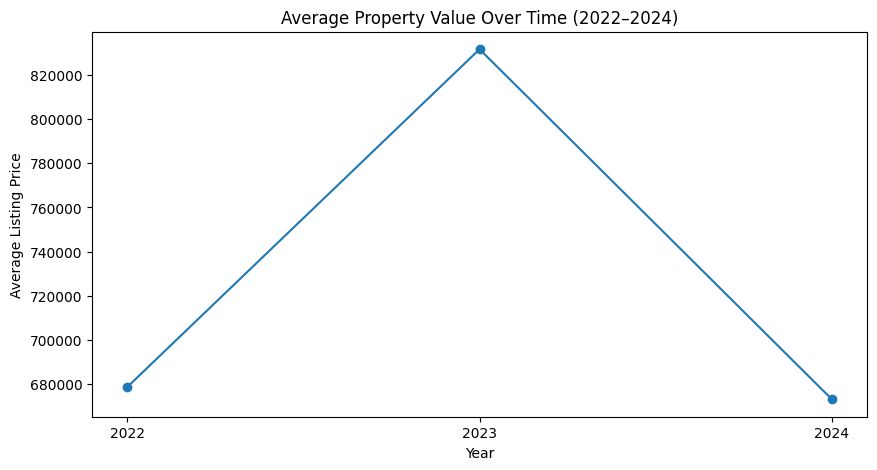

In [ ]:

plt.figure(figsize=(10, 5)) 

plt.plot(avg_price_by_year.index, avg_price_by_year.values, marker="o")

plt.title("Average Property Value Over Time (2022–2024)")
plt.xlabel("Year")
plt.ylabel("Average Listing Price")

# Showing each year as a tick to spread out the years
plt.xticks(avg_price_by_year.index)

plt.show()


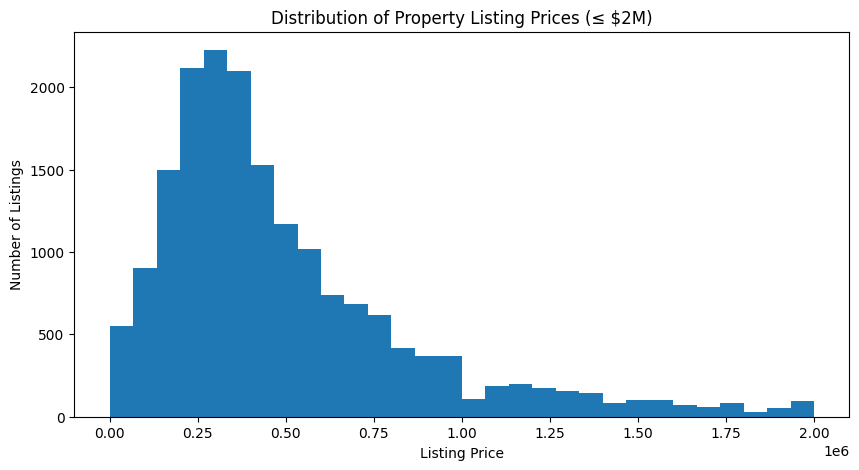

In [ ]:
# Focused on listings priced at $2M or less to better 
# visualize the distribution

plt.figure(figsize=(10, 5))
plt.hist(
    property_2022_2024[property_2022_2024["price"] <= 2_000_000]["price"],
    bins=30
)
plt.title("Distribution of Property Listing Prices (≤ $2M)")
plt.xlabel("Listing Price")
plt.ylabel("Number of Listings")
plt.show()


In [62]:
# This visualization helps identify which property types
# tend to have higher values and may be more attractive for investment.
avg_price_by_type = (
    property_2022_2024
    .groupby("homeType")["price"]
    .mean()
    .sort_values(ascending=False)
)

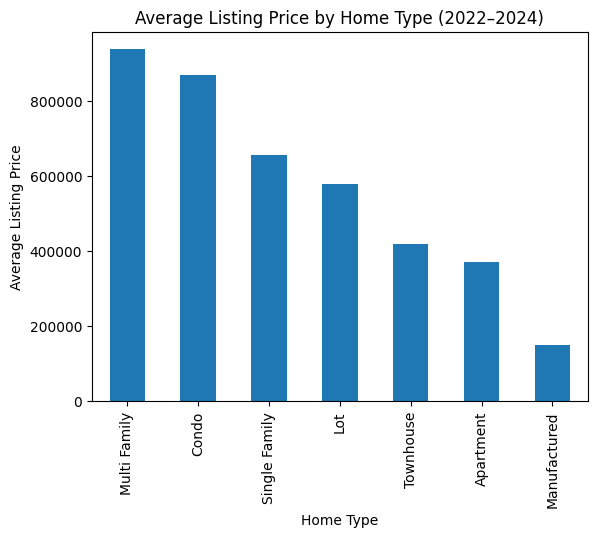

In [ ]:
# Looking for the average price by home type.
avg_price_by_type.plot(kind="bar")
plt.title("Average Listing Price by Home Type (2022–2024)")
plt.xlabel("Home Type")
plt.ylabel("Average Listing Price")
plt.show()

In [ ]:
# Looking at markets with higher property values,
# and hopefully indicate a stronger demand or investment potential.

avg_price_by_city = (
    property_2022_2024
    .groupby("city")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

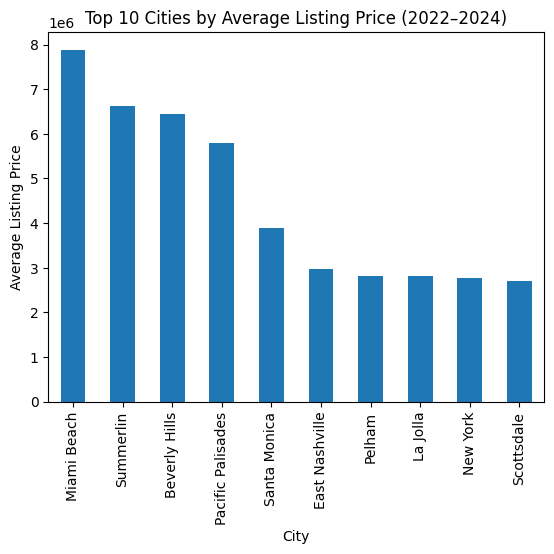

In [ ]:
# Looking at the top 10 cities by average listing price.

avg_price_by_city.plot(kind="bar")
plt.title("Top 10 Cities by Average Listing Price (2022–2024)")
plt.xlabel("City")
plt.ylabel("Average Listing Price")
plt.show()


## Summarize Your Results

With your EDA complete, answer the following questions.

1. Was there anything surprising about your dataset?

I was suprised about the wide range of property prices. Some were extremely high compared to most which my influence the averege prices. 

2. Do you have any concerns about your dataset? 

I am concerned about the columns with missing values. Will this limit certain analyses or require imputation or filtering. 

3. Is there anything you want to make note of for the next phase of your analysis, which is cleaning data? 

Yes, I want to take care of the missing values in what I think are important columns like, price, datePosted etc. & figure out if I need to filter my dataset by the status of the home, like: active vs sold listings to make sure the comparisons are consistent. 